# Credit Risk Analysis: Predicting Loan Default

**Author:** Guilherme Almeida

## Business problem
A lender loses money in two ways: approving a client who later defaults, and rejecting a good client who would have paid. This project builds a model that estimates each applicant's **probability of default**, so that the credit team can approve, review or reject loans based on risk, and quantifies how much that is worth.

## Dataset
[Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) (Kaggle): 32,581 loan records with applicant profile (age, income, home ownership, employment length), loan details (amount, intent, grade, interest rate) and credit history. The target is `loan_status` (1 = default, 0 = paid). About **22%** of the loans defaulted, so the classes are imbalanced.

## Approach
1. Clean the data (duplicates, impossible values, missing values).
2. Explore where default risk is concentrated.
3. Build leakage-free Pipelines and compare k-NN, Logistic Regression, Random Forest and XGBoost with stratified cross-validation.
4. Tune hyperparameters and the **decision threshold**, with recall on defaulters as the priority.
5. Translate model performance into money and explain the risk drivers with SHAP.
6. Score every client and group the portfolio into risk bands.

## Headline result
The improvement over the original k-NN has two separate sources, kept apart here because mixing them overstates the effect of the model:
- **The model.** At the same default 0.5 cutoff, the tuned XGBoost catches **80.5%** of defaulters against **61.1%** for k-NN, with the same precision (83.1% vs 82.6%).
- **The cutoff.** Lowering the decision threshold to 0.35, tuned for recall, lifts recall further to **86.1%**, but precision falls from 83.1% to **66.8%**. This is a trade-off, not a free gain.

The ROC-AUC is **0.95**, which is an upper bound for this dataset and not an expectation for real data (see the data check in section 8b). Used as a credit filter, the model cuts the simulated loss by about **81%** compared with approving every loan (under the illustrative assumptions in section 7, with calibrated probabilities and a threshold chosen without the test set).

In [1]:
# System and environment variables
import os
import re
import time
import inspect
from pathlib import Path
import joblib
from dotenv import load_dotenv

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization and analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning preprocessing and pipelines
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Machine Learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn
import xgboost
from xgboost import XGBClassifier

# Hyperparameter search distributions and model explainability
from scipy.stats import loguniform, randint, uniform
import shap

# Evaluation metrics
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                             precision_score, recall_score, fbeta_score, brier_score_loss,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

# Global seed for reproducibility
SEED = 42

# Disk cache for the slow steps (searches, cross-validation, calibration). A cached result is reused only if the
# input data, the settings, the code of the step, the seed and the library versions are all unchanged;
# delete the cache/ folder to force a full re-run. Only load cache files that you generated yourself (they are pickles).
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

def cached(name, compute, *inputs):
    """Run compute() once and store the result; later runs load it if `inputs` and compute's code are unchanged."""
    try:
        code = inspect.getsource(compute)
    except OSError:
        code = ''
    key = joblib.hash((inputs, code, SEED, sklearn.__version__, xgboost.__version__))[:12]
    path = CACHE_DIR / f"{re.sub(r'[^A-Za-z0-9]+', '_', name).strip('_')}_{key}.joblib"
    t0 = time.perf_counter()
    if path.exists():
        result, source = joblib.load(path), 'loaded from cache'
    else:
        result, source = compute(), 'computed'
        joblib.dump(result, path)
    print(f"{name}: {source} in {time.perf_counter() - t0:.0f} s")
    return result


## 1. Data acquisition
The dataset is downloaded from Kaggle through its API (the token is read from a local `.env` file that must never be committed). If `credit_risk_dataset.csv` already exists, the download is skipped.

In [2]:
# Download the dataset from Kaggle only if it is not already on disk
if os.path.exists('credit_risk_dataset.csv'):
    print("Dataset already present, skipping download.")
else:
    # Loading the environment variables containing the Kaggle API token
    load_dotenv('Kaggle_token.env')

    # Importing the Kaggle API after loading the environment variables
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate()

    print("Downloading and extracting dataset...")
    api.dataset_download_files('laotse/credit-risk-dataset', path='.', unzip=True)
    print("Dataset successfully downloaded and extracted.")

Dataset already present, skipping download.


## 2. First look at the data
A quick inspection of structure, types, summary statistics and a business question: the average loan by intent. Two data-quality problems show up here and are handled in the next section: **missing values** in `loan_int_rate` (~10%) and `person_emp_length` (~3%), and **impossible values** (ages up to 144, employment of 123 years).

In [3]:
# Reading the file
cr = pd.read_csv('credit_risk_dataset.csv')

In [4]:
# View of the first 5 rows
cr.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Statistical information about the data
cr.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
# Information about the columns
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# Average Loan amount by loan Intent
cr.groupby('loan_intent')['loan_amnt'].mean()

loan_intent
DEBTCONSOLIDATION     9594.886800
EDUCATION             9482.678599
HOMEIMPROVEMENT      10360.520111
MEDICAL               9259.582441
PERSONAL              9573.772867
VENTURE               9583.777758
Name: loan_amnt, dtype: float64

## 3. Data cleaning
- **Duplicates:** 165 exact duplicate rows removed.
- **Outliers:** 7 rows removed (age above 100 or employment length above 60 years). Rows with *missing* employment length are kept: a plain `<= 60` filter would silently drop them.
- **Missing values:** not filled here for modeling. Imputation happens inside the modeling Pipeline, fitted on the training data only, so no information from the test set leaks into training. A separately imputed copy (`cr_bi`, using the median interest rate per loan grade) is kept only for the Power BI export.

Result: 32,581 → **32,409** rows, with the same ~22% default rate.

In [8]:
# Data cleaning: remove duplicates and impossible values BEFORE imputing,
# and report how many rows each step removes
n_start = len(cr)

# 1) Exact duplicate rows
cr = cr.drop_duplicates()
n_dups = n_start - len(cr)

# 2) Extreme outliers: age above 100 years or employment length above 60 years.
# Missing employment length (NaN) is kept here and imputed in the next cell;
# a plain `<= 60` comparison would silently drop every NaN row.
n_before = len(cr)
cr = cr[(cr['person_age'] <= 100) & ((cr['person_emp_length'] <= 60) | cr['person_emp_length'].isna())]
n_outliers = n_before - len(cr)

print(f"Rows at start:          {n_start}")
print(f"Duplicates removed:     {n_dups}")
print(f"Outliers removed:       {n_outliers}")
print(f"Rows after cleaning:    {len(cr)}")

Rows at start:          32581
Duplicates removed:     165
Outliers removed:       7
Rows after cleaning:    32409


In [9]:
# Imputed copy used ONLY for the Power BI export (cr_bi).
# `cr` keeps its missing values: imputation for modeling happens inside the Pipeline,
# fitted on the training set only, to avoid data leakage.
cr_bi = cr.copy()

# loan_int_rate (~10% missing): the rate is tightly tied to loan_grade, so use the median per grade
cr_bi['loan_int_rate'] = cr_bi['loan_int_rate'].fillna(cr_bi.groupby('loan_grade')['loan_int_rate'].transform('median'))

# person_emp_length (~3% missing): overall median
cr_bi['person_emp_length'] = cr_bi['person_emp_length'].fillna(cr_bi['person_emp_length'].median())

In [10]:
# Missing values left in `cr` (handled inside the modeling Pipeline)
cr.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3094
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

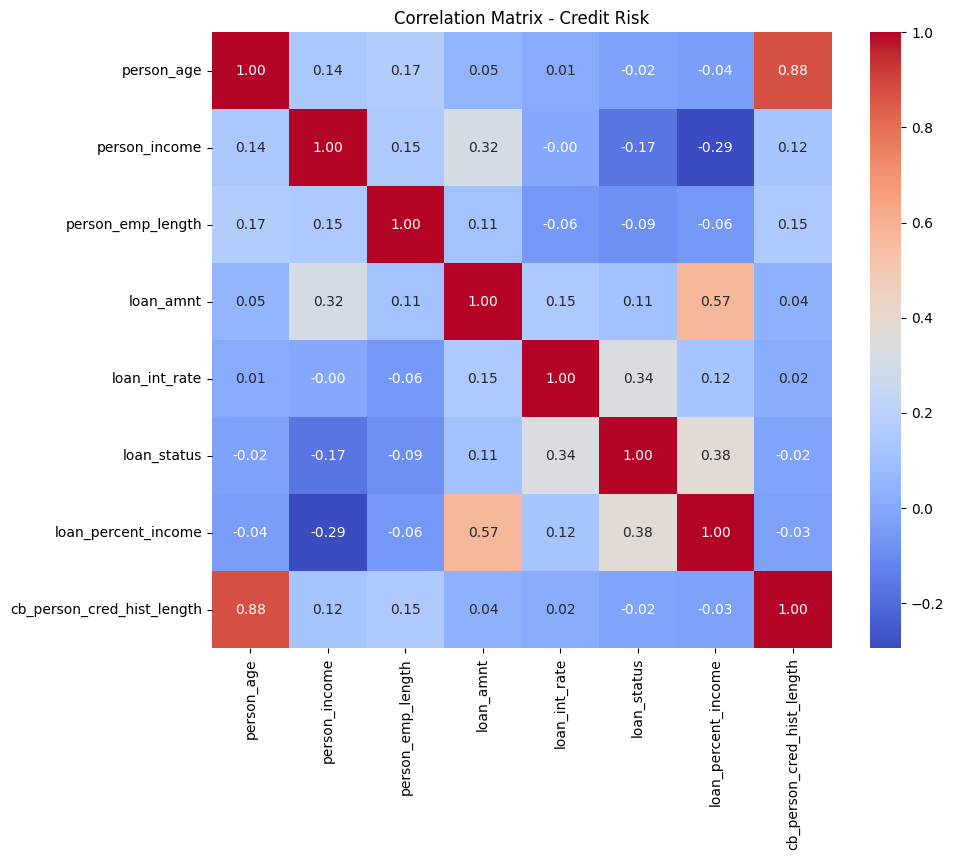

In [11]:
# Generating a correlation matrix for numerical features to identify relationships with loan_status
plt.figure(figsize=(10, 8))
correlation_matrix = cr.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Credit Risk")
plt.show()

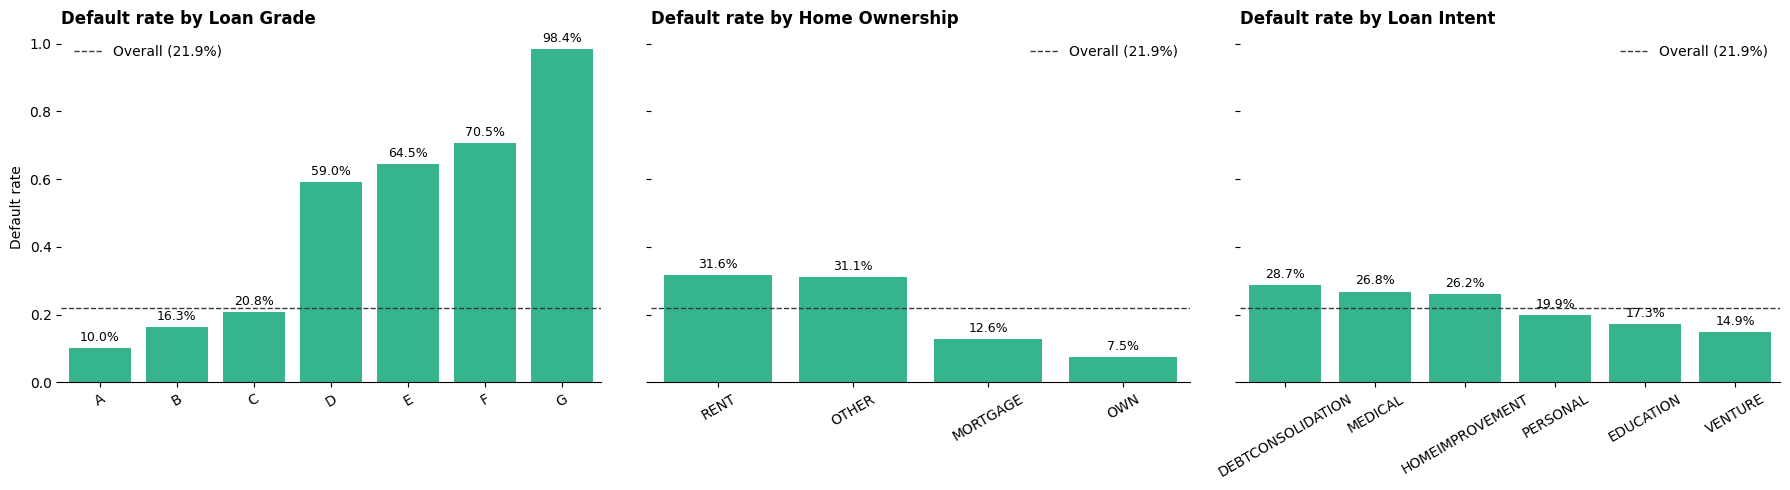

In [12]:
# Default rate by group: where is the risk concentrated?
overall_rate = cr['loan_status'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, col, title in zip(axes,
                          ['loan_grade', 'person_home_ownership', 'loan_intent'],
                          ['Loan Grade', 'Home Ownership', 'Loan Intent']):
    rate = cr.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    if col == 'loan_grade':
        rate = rate.sort_index()  # keep grades in A-G order
    sns.barplot(x=rate.index, y=rate.values, color="#20c997", ax=ax)
    ax.axhline(overall_rate, color='#343a40', linestyle='--', linewidth=1, label=f'Overall ({overall_rate:.1%})')
    ax.bar_label(ax.containers[0], labels=[f'{v:.1%}' for v in rate.values], padding=3, fontsize=9)
    ax.set_title(f"Default rate by {title}", fontweight='bold', loc='left')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
    ax.legend(frameon=False)
axes[0].set_ylabel("Default rate")
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [13]:

# --- Evidence for the debt-burden and prior-default statements below ---
lti, status = cr['loan_percent_income'], cr['loan_status']
prior = cr['cb_person_default_on_file']
debt_burden = pd.DataFrame({
    'Clients': {'Loan > 30% of income': (lti > 0.30).sum(), 'Loan < 10% of income': (lti < 0.10).sum(),
                'Prior default on file': (prior == 'Y').sum(), 'No prior default': (prior == 'N').sum()},
    'Default rate': {'Loan > 30% of income': status[lti > 0.30].mean(), 'Loan < 10% of income': status[lti < 0.10].mean(),
                     'Prior default on file': status[prior == 'Y'].mean(), 'No prior default': status[prior == 'N'].mean()},
})
debt_burden.round(3)


,Clients,Default rate
Loan > 30% of income,3818,0.704
Loan < 10% of income,8904,0.116
Prior default on file,5729,0.379
No prior default,26680,0.184


### Where is the risk concentrated?
The overall default rate is **21.9%**. The groups that stand out:
- **Loan grade is the strongest signal.** Default climbs from 10.0% (grade A) to 20.8% (C), then jumps to **59.0% (D)**, 64.5% (E), 70.5% (F) and 98.4% (G).
- **Home ownership:** renters (31.6%) default more than four times as often as owners (7.5%); mortgage holders sit at 12.6%.
- **Loan intent:** debt consolidation (28.7%), medical (26.8%) and home improvement (26.2%) are riskier than venture (14.9%) and education (17.3%).
- **Debt burden:** clients whose loan is more than 30% of their income default 70.4% of the time, against 11.6% when it is below 10% (computed in the cell above). A prior default on file nearly doubles the rate (37.9% vs 18.4%, same cell).

These are descriptive patterns; the model below combines them to score each applicant.

## 4. Modeling setup
Features and target are separated, and the data is split **70/30 with stratification** so both sets keep the same default rate. The preprocessing recipe (median imputation with missing-value flags, scaling where needed, one-hot encoding) lives inside each Pipeline.

In [14]:
# Separating features (X) and the target variable (y)
X = cr.drop('loan_status', axis=1)
y = cr['loan_status']

In [15]:
# Column groups and preprocessing recipe.
# Imputation, encoding and scaling live inside the Pipeline, so they are fitted
# on training data only (inside each CV fold as well) and never leak test information.
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

def make_preprocessor(scale=False, drop=()):
    """Median imputation (+ missing-value flags) and optional scaling for numeric columns; one-hot for categoricals.
    `drop` removes variables entirely (used by the circularity and age tests)."""
    num_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        num_steps.append(('scaler', StandardScaler()))  # needed by k-NN and Logistic Regression
    return ColumnTransformer([
        ('num', Pipeline(num_steps), [c for c in num_cols if c not in drop]),
        ('cat', OneHotEncoder(handle_unknown='ignore'), [c for c in cat_cols if c not in drop]),
    ])

In [16]:
# Splitting the dataset into training (70%) and testing (30%) sets.
# stratify=y keeps the ~22% default rate identical in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

print(f"Total data:   {len(X)}")
print(f"Training set: {len(X_train)} (default rate {y_train.mean():.1%})")
print(f"Test set:     {len(X_test)} (default rate {y_test.mean():.1%})")

Total data:   32409
Training set: 22686 (default rate 21.9%)
Test set:     9723 (default rate 21.9%)


In [17]:
# Models, each wrapped in a Pipeline together with its preprocessing.
# The imbalance (~22% defaults) is handled with class weights instead of resampling.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    # Original baseline
    'k-NN': Pipeline([
        ('prep', make_preprocessor(scale=True)),
        ('model', KNeighborsClassifier(n_neighbors=5)),
    ]),
    # Interpretable baseline
    'Logistic Regression': Pipeline([
        ('prep', make_preprocessor(scale=True)),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)),
    ]),
    'Random Forest': Pipeline([
        ('prep', make_preprocessor()),
        ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced',
                                         n_jobs=-1, random_state=SEED)),
    ]),
    'XGBoost': Pipeline([
        ('prep', make_preprocessor()),
        ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                                colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                                eval_metric='logloss', n_jobs=-1, random_state=SEED)),
    ]),
}

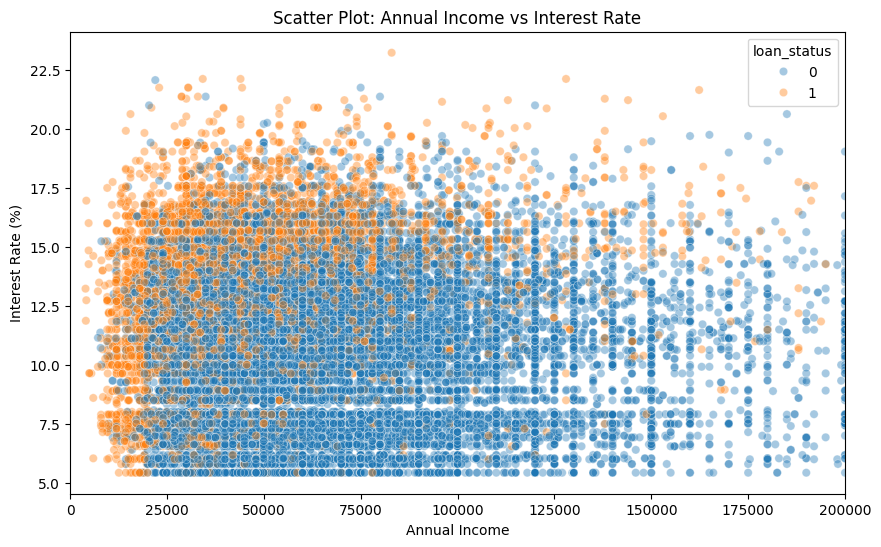

In [18]:
# Generating a Scatter Plot to visualize the separation of classes (Default vs Paid)
plt.figure(figsize=(10, 6))

# Plotting Income vs Interest Rate, coloring by loan_status
# alpha=0.4 makes points transparent to reveal overlapping data density
sns.scatterplot(data=cr, x='person_income', y='loan_int_rate', hue='loan_status', alpha=0.4)

# Limiting the X axis to 200,000 to avoid extreme outliers squishing the plot
plt.xlim(0, 200000)

plt.title("Scatter Plot: Annual Income vs Interest Rate")
plt.xlabel("Annual Income")
plt.ylabel("Interest Rate (%)")
plt.show()

## 5. Candidate models and hyperparameter tuning
Four model families are compared, from simple to powerful:
- **k-NN:** the original baseline.
- **Logistic Regression:** interpretable baseline with class weights.
- **Random Forest** and **XGBoost:** tree ensembles that capture non-linear effects and interactions, with the class imbalance handled through `class_weight` / `scale_pos_weight`.

The two tree models are then tuned with `RandomizedSearchCV` (5-fold, scored by **PR-AUC**, which focuses on the minority class and does not depend on the decision threshold). The search sees only the training set.

In [19]:
# --- Hyperparameter tuning (RandomizedSearchCV) for the two tree-based models ---
# Scoring is PR-AUC (average precision): it focuses on the minority class (defaulters) and does not
# depend on a decision threshold, which is tuned later. The search only sees the TRAINING set.
cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search_spaces = {
    'XGBoost': {
        'model__n_estimators': randint(200, 800),
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__max_depth': randint(3, 9),
        'model__min_child_weight': randint(1, 11),
        'model__subsample': uniform(0.6, 0.4),          # 0.6 - 1.0
        'model__colsample_bytree': uniform(0.6, 0.4),   # 0.6 - 1.0
        'model__gamma': uniform(0, 5),
        'model__reg_lambda': loguniform(0.1, 10),
    },
    'Random Forest': {   # n_estimators is fixed (150 during the search, 400 in the final refit)
        'model__max_depth': [10, 15, 20],
        'model__min_samples_leaf': randint(1, 10),
        'model__max_features': ['sqrt', 'log2'],
    },
}
n_iter = {'XGBoost': 40, 'Random Forest': 8}

def describe(space):
    """Stable description of a search space (scipy distributions carry a global RNG state that must not enter the cache key)."""
    return {k: (v.dist.name, v.args, v.kwds) if hasattr(v, 'dist') else v for k, v in space.items()}

tuned_models, tuning_summary = {}, []
for name, space in search_spaces.items():
    base = models[name]
    search_jobs = 1
    if name == 'Random Forest':   # cheaper forests while searching
        base = clone(base).set_params(model__n_estimators=150)
    elif name == 'XGBoost':       # one thread per fit; the search parallelises across fits instead
        base = clone(base).set_params(model__n_jobs=1)
        search_jobs = -1

    def run_search():
        search = RandomizedSearchCV(base, space, n_iter=n_iter[name], scoring='average_precision',
                                    cv=cv_search, random_state=SEED, n_jobs=search_jobs).fit(X_train, y_train)
        best = search.best_estimator_   # already refitted on the full training set
        if name == 'Random Forest':   # final refit with 400 trees
            best = clone(best).set_params(model__n_estimators=400).fit(X_train, y_train)
        if name == 'XGBoost':         # back to all threads for the training steps that follow
            best.set_params(model__n_jobs=-1)
        default_cv = cross_validate(models[name], X_train, y_train, cv=cv_search,
                                    scoring='average_precision')['test_score'].mean()
        return best, search.best_score_, search.best_params_, default_cv

    best, best_score, best_params, default_cv = cached(
        f'search_{name}', run_search,
        X_train, y_train, base, describe(space), n_iter[name], models[name], repr(cv_search))
    tuned_models[f'{name} (tuned)'] = best
    tuning_summary.append({
        'Model': name,
        'Default CV PR-AUC': default_cv,
        'Tuned CV PR-AUC': best_score,
        'Best params': {k.replace('model__', ''): (round(v, 4) if isinstance(v, float) else v)
                        for k, v in best_params.items()},
    })

# The tuned models join the comparison alongside the default ones
models.update(tuned_models)
pd.DataFrame(tuning_summary).set_index('Model').round(4)

search_XGBoost: loaded from cache in 1 s
search_Random Forest: loaded from cache in 0 s


,Default CV PR-AUC,Tuned CV PR-AUC,Best params
Model,,,
XGBoost,0.8979,0.9015,"{'colsample_bytree': 0.7826, 'gamma': 1.0922, ..."
Random Forest,0.8785,0.8723,"{'max_depth': 15, 'max_features': 'sqrt', 'min..."


**Tuning outcome:** for XGBoost the gain is real but modest (cross-validated PR-AUC 0.898 → 0.902). For Random Forest the search was deliberately kept small to save time (8 candidates, 150 trees per candidate, narrower grid, final refit with 400 trees) and it did **not** beat the default configuration (0.879 → 0.872), so the tuned forest is slightly worse than the default one. The default configurations were already close to the ceiling for this data, which says the bigger lever is not tuning but the choice of model family and the decision threshold.

## 6. Cross-validation, threshold tuning and test results
- **Cross-validation (training set only)** shows the mean and variability of each metric. A single split can be lucky; here the ROC-AUC varies by less than 0.01 across folds, so the ranking of models is stable.
- **Threshold tuning:** a classifier flags a default when its probability exceeds a cutoff, and 0.5 is rarely right for imbalanced data. The cutoff is chosen to maximize the **F2 score** (recall weighs twice as much as precision, because missing a defaulter costs more than refusing a good client). It is chosen on out-of-fold predictions of the training set, so the test set stays untouched.
- **Final evaluation** on the 30% held-out test set.

In [20]:
# --- 5-fold stratified cross-validation + decision threshold tuning, on the TRAINING set ---
# Each fold is fitted ONCE per model; its predictions feed both the CV metrics (mean and variability)
# and the out-of-fold probabilities used to tune the threshold and to pick the best model.
#
# Decision threshold: F2 score, which weighs recall twice as much as precision. In credit risk, missing a
# defaulter (false negative) is costlier than refusing a good client. BOTH the threshold and the choice of
# the best model use out-of-fold predictions of the TRAINING set, so the test set plays no part in any
# decision and is used only to report results.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
thresholds = np.linspace(0.05, 0.95, 91)
cv_rows, best_threshold, oof_proba, oof_f2 = [], {}, {}, {}

for name, pipe in models.items():
    def run_cv():
        oof = np.zeros(len(y_train))
        folds = []
        for tr, va in cv.split(X_train, y_train):
            p = clone(pipe).fit(X_train.iloc[tr], y_train.iloc[tr]).predict_proba(X_train.iloc[va])[:, 1]
            oof[va] = p
            yv = y_train.iloc[va]
            # recall uses `p > 0.5`, which matches predict() (a tie at exactly 0.5 goes to the negative class)
            folds.append((roc_auc_score(yv, p), average_precision_score(yv, p), recall_score(yv, p > 0.5)))
        return np.array(folds), oof

    folds, oof = cached(f'cv_{name}', run_cv, X_train, y_train, clone(pipe), repr(cv))
    cv_rows.append({
        'Model': name,
        'ROC-AUC': folds[:, 0].mean(),
        'ROC-AUC (std)': folds[:, 0].std(),
        'PR-AUC': folds[:, 1].mean(),
        'Recall @ 0.5': folds[:, 2].mean(),
    })
    oof_proba[name] = oof
    f2_scores = [fbeta_score(y_train, oof >= t, beta=2) for t in thresholds]
    best_threshold[name] = thresholds[int(np.argmax(f2_scores))]
    oof_f2[name] = max(f2_scores)

cv_results = pd.DataFrame(cv_rows).set_index('Model').round(3)
display(cv_results)

# Best model = highest out-of-fold F2 at its own tuned threshold
best_name = max(oof_f2, key=oof_f2.get)
print(f"Best model (out-of-fold F2 on the training set): {best_name}")

pd.DataFrame({'Tuned threshold': best_threshold, 'OOF F2 (train)': oof_f2}).round(3)

cv_k-NN: loaded from cache in 0 s
cv_Logistic Regression: loaded from cache in 0 s
cv_Random Forest: loaded from cache in 0 s
cv_XGBoost: loaded from cache in 0 s
cv_XGBoost (tuned): loaded from cache in 0 s
cv_Random Forest (tuned): loaded from cache in 0 s


,ROC-AUC,ROC-AUC (std),PR-AUC,Recall @ 0.5
Model,,,,
k-NN,0.855,0.007,0.717,0.594
Logistic Regression,0.872,0.008,0.721,0.783
Random Forest,0.928,0.006,0.878,0.722
XGBoost,0.945,0.008,0.898,0.793
XGBoost (tuned),0.947,0.008,0.901,0.789
Random Forest (tuned),0.926,0.006,0.873,0.754


Best model (out-of-fold F2 on the training set): XGBoost (tuned)


,Tuned threshold,OOF F2 (train)
k-NN,0.05,0.701
Logistic Regression,0.50,0.723
Random Forest,0.25,0.785
XGBoost,0.36,0.810
XGBoost (tuned),0.35,0.814
Random Forest (tuned),0.35,0.779


In [21]:
# --- Final fit on the full training set and evaluation on the held-out TEST set ---
test_proba = {}
test_rows = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    test_proba[name] = proba

    for label, t in (('0.5', 0.5), ('tuned', best_threshold[name])):
        pred = proba >= t
        test_rows.append({
            'Model': name,
            'Threshold': label,
            't': round(t, 2),
            'Accuracy': (pred == y_test).mean(),
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F2': fbeta_score(y_test, pred, beta=2),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'PR-AUC': average_precision_score(y_test, proba),
        })

results_df = pd.DataFrame(test_rows).round(3)
results_df

,Model,Threshold,t,Accuracy,Precision,Recall,F2,ROC-AUC,PR-AUC
0,k-NN,0.5,0.50,0.887,0.826,0.611,0.645,0.865,0.735
1,k-NN,tuned,0.05,0.709,0.419,0.860,0.711,0.865,0.735
2,Logistic Regression,0.5,0.50,0.807,0.541,0.777,0.714,0.870,0.708
3,Logistic Regression,tuned,0.50,0.807,0.541,0.777,0.714,0.870,0.708
4,Random Forest,0.5,0.50,0.931,0.940,0.730,0.765,0.933,0.886
5,Random Forest,tuned,0.25,0.865,0.648,0.833,0.788,0.933,0.886
6,XGBoost,0.5,0.50,0.918,0.816,0.804,0.807,0.948,0.905
7,XGBoost,tuned,0.36,0.868,0.648,0.869,0.814,0.948,0.905
8,XGBoost (tuned),0.5,0.50,0.922,0.831,0.805,0.810,0.950,0.907
9,XGBoost (tuned),tuned,0.35,0.876,0.668,0.861,0.814,0.950,0.907


### Reading the results
- **Tree ensembles clearly beat the linear and distance-based models** (ROC-AUC 0.93-0.95 vs 0.87 for both Logistic Regression and k-NN). The next test shows why: default risk depends on combinations of variables, which trees learn naturally.
- **The best model is the tuned XGBoost**, chosen by out-of-fold F2 on the training set (not by test results). On the test set: ROC-AUC 0.950, PR-AUC 0.907. Its recall advantage over the original k-NN (61.1% at the default 0.5 cutoff) has two separate parts:
  - *The model:* at the same 0.5 cutoff the tuned XGBoost catches **80.5%** of defaulters with 83.1% precision, against 61.1% and 82.6% for k-NN. That is about 19 points more recall with no loss of precision.
  - *The cutoff:* lowering it to the tuned 0.35 raises recall to **86.1%**, but precision falls from 83.1% to **66.8%**. This is a trade-off, not a free gain, and it is the right call only when a missed default costs more than reviewing an extra client.
- **A recall-first cutoff helps every model, so compare models at the same cutoff.** At its own tuned cutoff (0.05) k-NN also reaches 86.0% recall, but with only 41.9% precision, against 66.8% for the XGBoost.
- Cross-validation and test scores agree (ROC-AUC 0.947 in CV vs 0.950 on the test set), so there is no sign of overfitting.

,ROC-AUC,PR-AUC
Model,,
Logistic Regression (no interactions),0.872,0.721
Logistic Regression + pairwise interactions,0.906,0.816
"XGBoost, depth 1",0.896,0.763
"XGBoost, depth 2",0.924,0.861
"XGBoost, depth 3",0.935,0.882
"XGBoost, depth 4",0.942,0.893
"XGBoost, depth 6",0.946,0.900


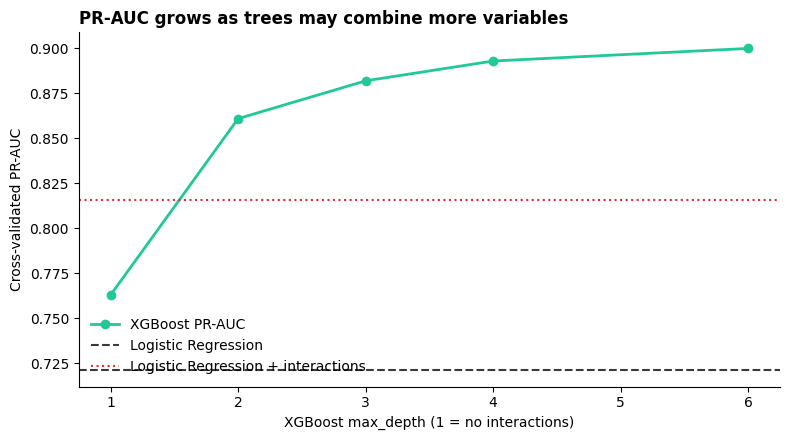

In [22]:
# --- Why do tree ensembles win? Testing the "interactions" hypothesis ---
# XGBoost with max_depth=1 is an ADDITIVE model: each tree splits on a single variable, so no interactions
# can be learned (it can still capture non-linear effects). Each extra level of depth allows one more level
# of variable interactions. Comparing depths therefore isolates how much interactions are worth.
# Logistic Regression is also tested with all pairwise interaction terms added by hand.
def xgb_with_depth(depth):
    return Pipeline([
        ('prep', make_preprocessor()),
        ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=depth, subsample=0.8,
                                colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                                eval_metric='logloss', n_jobs=-1, random_state=SEED)),
    ])

lr_interactions = Pipeline([
    ('prep', make_preprocessor(scale=True)),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', C=0.1, random_state=SEED)),
])

ablation = {
    'Logistic Regression (no interactions)': models['Logistic Regression'],
    'Logistic Regression + pairwise interactions': lr_interactions,
    **{f'XGBoost, depth {d}': xgb_with_depth(d) for d in (1, 2, 3, 4, 6)},
}

ablation_rows = []
for name, pipe in ablation.items():
    s = cross_validate(pipe, X_train, y_train, cv=cv,
                       scoring={'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'})
    ablation_rows.append({'Model': name, 'ROC-AUC': s['test_roc_auc'].mean(), 'PR-AUC': s['test_pr_auc'].mean()})

ablation_df = pd.DataFrame(ablation_rows).set_index('Model').round(3)
display(ablation_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
depth_rows = ablation_df.loc[[f'XGBoost, depth {d}' for d in (1, 2, 3, 4, 6)]]
ax.plot([1, 2, 3, 4, 6], depth_rows['PR-AUC'], marker='o', color="#20c997", linewidth=2, label='XGBoost PR-AUC')
ax.axhline(ablation_df.loc['Logistic Regression (no interactions)', 'PR-AUC'], color='#343a40', linestyle='--', label='Logistic Regression')
ax.axhline(ablation_df.loc['Logistic Regression + pairwise interactions', 'PR-AUC'], color='#e03131', linestyle=':', label='Logistic Regression + interactions')
ax.set_title("PR-AUC grows as trees may combine more variables", fontweight='bold', loc='left')
ax.set_xlabel("XGBoost max_depth (1 = no interactions)")
ax.set_ylabel("Cross-validated PR-AUC")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### What the interaction test shows
The hypothesis holds, with two separate effects visible in the table and chart above:
- **Non-linearity helps a little.** XGBoost with `max_depth=1` (additive: no interactions) already beats Logistic Regression (ROC-AUC 0.896 vs 0.872, PR-AUC 0.763 vs 0.721).
- **Interactions help a lot.** Allowing trees to combine just two variables (`max_depth=2`) lifts PR-AUC from 0.763 to 0.861, the largest single jump, and it keeps improving up to depth 6 (PR-AUC 0.900, ROC-AUC 0.946).
- **Interactions also help the linear model:** adding all pairwise terms to Logistic Regression raises its PR-AUC from 0.721 to 0.816, but it still falls short of the trees (0.900) without any manual feature engineering.

In practice, default risk depends on *combinations* (for example loan grade together with the loan-to-income ratio), not only on each variable alone.


### How much signal is left without the lender's own risk score?
`loan_grade` and `loan_int_rate` are decided by the lender *before* the loan, so they may simply replay an earlier credit assessment (circularity). The best model is retrained without them (and, separately, without `person_age`, a variable that is sensitive in credit decisions; see section 9). Each variant has its own threshold, tuned on out-of-fold predictions of the training set.


In [23]:

# --- Circularity and age test: retrain the best model without selected variables ---
variants = {
    'All variables': [],
    'Without loan_grade': ['loan_grade'],
    'Without loan_grade and loan_int_rate': ['loan_grade', 'loan_int_rate'],
    'Without person_age': ['person_age'],
}

circ_rows = []
for label, dropped in variants.items():
    def run_variant():
        pipe = clone(models[best_name]).set_params(prep=make_preprocessor(drop=dropped))
        X_tr, X_te = X_train.drop(columns=dropped), X_test.drop(columns=dropped)

        s = cross_validate(pipe, X_tr, y_train, cv=cv, scoring={'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'})
        oof = cross_val_predict(pipe, X_tr, y_train, cv=cv, method='predict_proba')[:, 1]
        t = thresholds[int(np.argmax([fbeta_score(y_train, oof >= t_, beta=2) for t_ in thresholds]))]

        pipe.fit(X_tr, y_train)
        p = pipe.predict_proba(X_te)[:, 1]
        return {
            'Variant': label,
            'CV ROC-AUC': s['test_roc_auc'].mean(),
            'CV PR-AUC': s['test_pr_auc'].mean(),
            'Threshold': t,
            'Test recall': recall_score(y_test, p >= t),
            'Test precision': precision_score(y_test, p >= t),
            'Test ROC-AUC': roc_auc_score(y_test, p),
        }

    circ_rows.append(cached(f'circularity_{label}', run_variant, X_train, y_train, X_test, y_test,
                            clone(models[best_name]), make_preprocessor(drop=dropped), dropped,
                            thresholds, repr(cv)))

circularity_df = pd.DataFrame(circ_rows).set_index('Variant').round(3)
circularity_df


circularity_All variables: loaded from cache in 0 s
circularity_Without loan_grade: loaded from cache in 0 s
circularity_Without loan_grade and loan_int_rate: loaded from cache in 0 s
circularity_Without person_age: loaded from cache in 0 s


,CV ROC-AUC,CV PR-AUC,Threshold,Test recall,Test precision,Test ROC-AUC
Variant,,,,,,
All variables,0.947,0.901,0.35,0.861,0.668,0.950
Without loan_grade,0.938,0.884,0.34,0.863,0.627,0.941
Without loan_grade and loan_int_rate,0.899,0.812,0.33,0.852,0.501,0.904
Without person_age,0.946,0.898,0.35,0.859,0.663,0.948


**Reading the test.** Removing `loan_grade` costs little (test ROC-AUC 0.950 → 0.941): `loan_int_rate` carries most of the same information, because the rate is itself set from the grade. Removing **both** hurts clearly (ROC-AUC 0.904, CV PR-AUC 0.901 → 0.812, precision at the tuned threshold 67% → 50%), so part of the model's power is reproducing the lender's own pricing.

But the model does **not** collapse: with only applicant data (income, home ownership, loan intent, loan-to-income, credit history) it still reaches a ROC-AUC of about 0.90 and keeps recall near 85%. The independent signal is real; the headline 0.95 is the upper bound when the lender's own score is allowed in.

Dropping `person_age` costs almost nothing (ROC-AUC 0.950 → 0.948, recall 86.1% → 85.9%), which matters for the compliance discussion in section 9: the variable can be removed with negligible loss.

Best model: XGBoost (tuned) (threshold = 0.35)


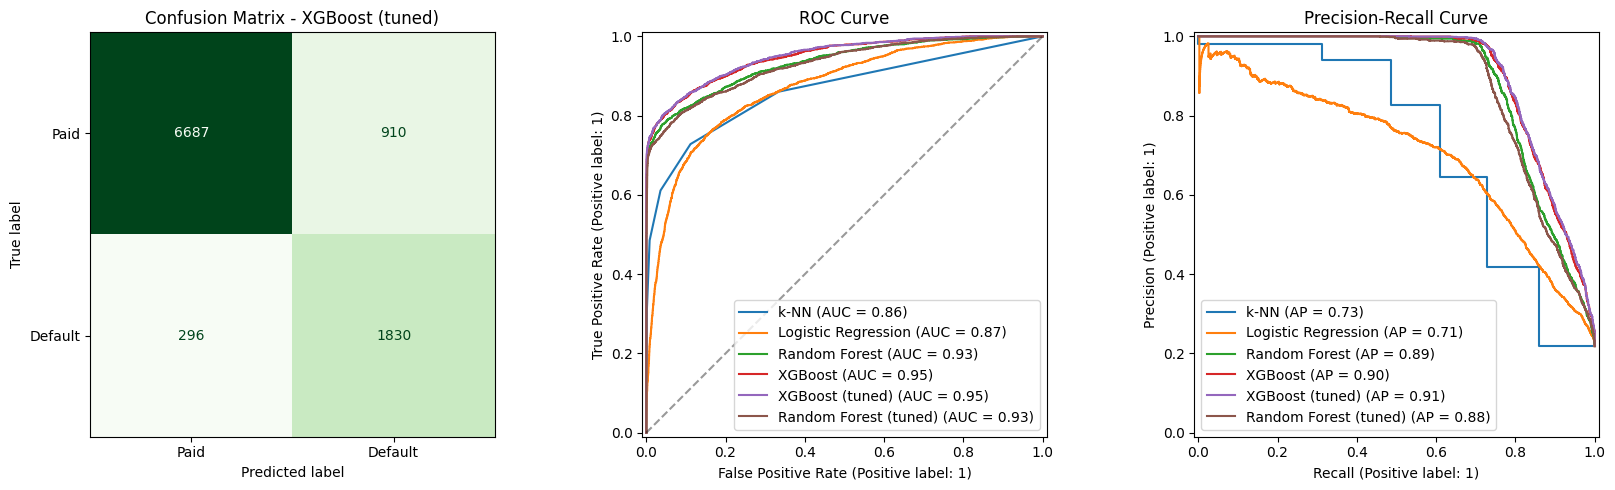

In [24]:
# --- Best model: confusion matrix, ROC and Precision-Recall curves (test set) ---
# `best_name` was chosen on out-of-fold F2 of the training set (section 6), not on the test results
best_model = models[best_name]
best_pred = test_proba[best_name] >= best_threshold[best_name]
print(f"Best model: {best_name} (threshold = {best_threshold[best_name]:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['Paid', 'Default'],
                                        cmap='Greens', colorbar=False, ax=axes[0])
axes[0].set_title(f"Confusion Matrix - {best_name}")

for name, proba in test_proba.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[2])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title("ROC Curve")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [25]:
# --- Detailed classification report of the best model (tuned threshold) ---
print(f"--- {best_name} (threshold = {best_threshold[best_name]:.2f}) ---")
print(classification_report(y_test, best_pred, target_names=['Paid', 'Default']))

--- XGBoost (tuned) (threshold = 0.35) ---
              precision    recall  f1-score   support

        Paid       0.96      0.88      0.92      7597
     Default       0.67      0.86      0.75      2126

    accuracy                           0.88      9723
   macro avg       0.81      0.87      0.83      9723
weighted avg       0.89      0.88      0.88      9723




## 6b. Probability calibration
`scale_pos_weight` / `class_weight` make the model care more about defaulters, which is good for ranking and recall but **distorts the probabilities**: a score of 0.40 does not mean a 40% chance of default. The business analysis below multiplies probabilities by money (`PD x LGD x EAD`), so it needs probabilities that mean what they say. The best model is wrapped in `CalibratedClassifierCV` (isotonic regression, fitted with 5-fold cross-fitting on the training set) and checked with the **Brier score** (mean squared error of the probabilities; lower is better) and a calibration curve on the test set.


calibration: loaded from cache in 0 s


,Raw,Calibrated
Brier score,0.064,0.052
Mean predicted PD,0.292,0.221
ROC-AUC,0.950,0.949
Recall @ tuned t,0.861,0.855
Tuned threshold,0.350,0.170
Observed default rate,0.219,0.219


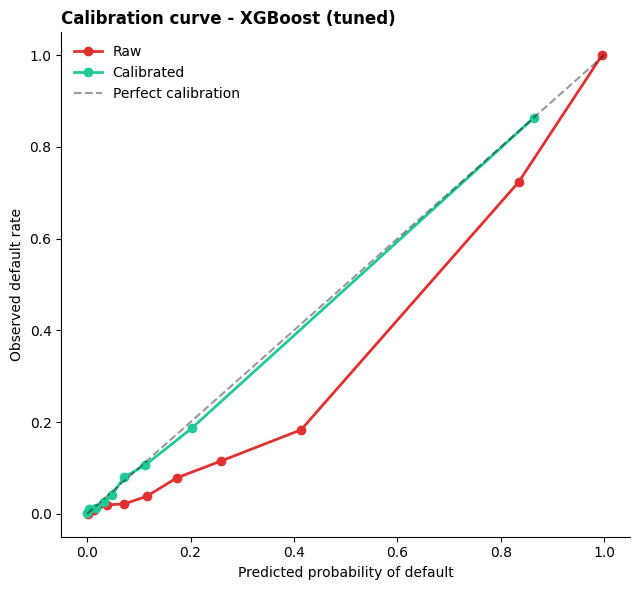

In [26]:

# --- Calibrate the best model and compare raw vs calibrated probabilities ---
def run_calibration():
    cal = CalibratedClassifierCV(clone(models[best_name]), method='isotonic', cv=5).fit(X_train, y_train)
    # Out-of-fold calibrated probabilities on the TRAINING set: used to choose thresholds without touching the test set
    oof = cross_val_predict(clone(cal), X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    return cal, oof

calibrated_model, cal_oof_proba = cached('calibration', run_calibration,
                                         X_train, y_train, clone(models[best_name]), repr(cv))

raw_test_proba = test_proba[best_name]
cal_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

cal_f2 = [fbeta_score(y_train, cal_oof_proba >= t, beta=2) for t in thresholds]
cal_threshold = thresholds[int(np.argmax(cal_f2))]

calibration_df = pd.DataFrame({
    'Raw': {'Brier score': brier_score_loss(y_test, raw_test_proba),
            'Mean predicted PD': raw_test_proba.mean(),
            'ROC-AUC': roc_auc_score(y_test, raw_test_proba),
            'Recall @ tuned t': recall_score(y_test, raw_test_proba >= best_threshold[best_name]),
            'Tuned threshold': best_threshold[best_name]},
    'Calibrated': {'Brier score': brier_score_loss(y_test, cal_test_proba),
                   'Mean predicted PD': cal_test_proba.mean(),
                   'ROC-AUC': roc_auc_score(y_test, cal_test_proba),
                   'Recall @ tuned t': recall_score(y_test, cal_test_proba >= cal_threshold),
                   'Tuned threshold': cal_threshold},
}).round(3)
calibration_df.loc['Observed default rate'] = [round(y_test.mean(), 3)] * 2
display(calibration_df)

fig, ax = plt.subplots(figsize=(6.5, 6))
for label, p, color in (('Raw', raw_test_proba, '#e03131'), ('Calibrated', cal_test_proba, '#20c997')):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', color=color, linewidth=2, label=label)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_title(f"Calibration curve - {best_name}", fontweight='bold', loc='left')
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Observed default rate")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


**Reading the calibration.** The raw model **overstates risk**: its average predicted PD is 29.2% against an observed default rate of 21.9%, as expected with `scale_pos_weight`. After isotonic calibration the average is 22.1% and the Brier score improves from 0.064 to 0.052, while ranking power is unchanged (ROC-AUC 0.950 vs 0.949) and recall at the tuned threshold stays at about 86%.

Calibrated scores sit on a different scale, so the F2 threshold moves from 0.35 to **0.17**. From here on, thresholds, costs, risk bands and `expected_loss` use the calibrated probabilities.

## 7. Business impact: what is the model worth?
Accuracy and recall do not say how much money is at stake, so the threshold is also evaluated on **cost**. This section uses the **calibrated** probabilities from section 6b. The two errors are not equally expensive:
- **Approving a client who defaults** loses `LGD x loan amount` (Loss Given Default, assumed at 60%).
- **Rejecting a client who would have paid** forgoes the interest income (loan amount x interest rate, one year).

**Expected loss, IFRS 9 style.** The natural way to read the model in a European bank is the expected credit loss, `ECL = PD x LGD x EAD`: the model supplies the **PD** (probability of default over the loan's life), **LGD** is the assumed 60% and **EAD** (exposure at default) is the loan amount, which assumes the loan is fully drawn and ignores amortization. This is a simplification of IFRS 9: it is a single through-the-cycle snapshot, with no staging (stage 1/2/3), no discounting and no forward-looking macroeconomic scenarios.

The cost-optimal threshold is chosen on **out-of-fold training predictions**; the test set is used only to report the resulting cost.

> **These cost assumptions are illustrative.** They are not in the data, so a sensitivity analysis below checks which conclusions survive when they change. Replace `LGD` and the income formula with the institution's real figures to get real amounts.

Approve everyone (no model):                    $  13,968,090
Model, F2 threshold (0.17):                   $   2,673,278
Model, cost-optimal threshold (0.17, from train): $   2,673,278
Savings vs. no model:                           80.9%


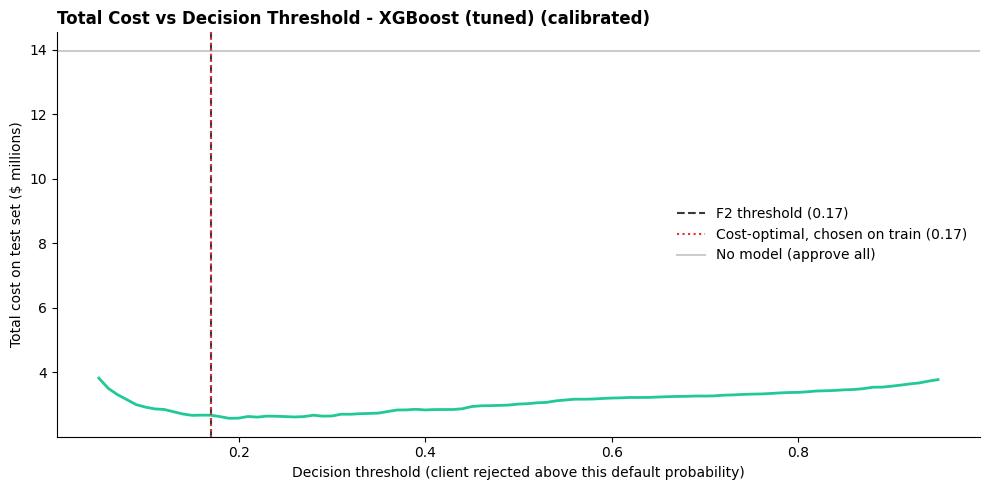

In [27]:
# --- Business impact: choosing the threshold by financial cost ---
# ILLUSTRATIVE ASSUMPTIONS (replace with the institution's real figures):
#  - Approving a client who defaults loses LGD (Loss Given Default) x loan amount (EAD).
#  - Rejecting a client who would have paid forgoes the interest income (loan amount x interest rate, 1 year).
# Probabilities are the CALIBRATED ones, so PD x LGD x EAD is a meaningful expected loss.
LGD = 0.60

def cost_inputs(X_part, y_part):
    """Loan amounts (EAD), one-year interest income and default flags of a data subset."""
    amount = X_part['loan_amnt'].to_numpy()
    income = amount * X_part['loan_int_rate'].fillna(X_train['loan_int_rate'].median()).to_numpy() / 100
    return amount, income, y_part.to_numpy() == 1

def total_cost(proba, threshold, part, lgd=LGD, years=1):
    amount, income, is_default = part
    reject = proba >= threshold                                      # flagged as high risk -> loan denied
    missed_defaults = (amount * lgd)[~reject & is_default].sum()     # false negatives
    lost_interest = (income * years)[reject & ~is_default].sum()     # false positives
    return missed_defaults + lost_interest

train_part, test_part = cost_inputs(X_train, y_train), cost_inputs(X_test, y_test)

# Thresholds are chosen on out-of-fold TRAINING predictions; the test set only reports the result
cost_curve_train = pd.Series({t: total_cost(cal_oof_proba, t, train_part) for t in thresholds})
cost_optimal_threshold = cost_curve_train.idxmin()
cost_curve_test = pd.Series({t: total_cost(cal_test_proba, t, test_part) for t in thresholds})   # for the chart only

cost_no_model = total_cost(cal_test_proba, 1.01, test_part)      # nobody rejected = approve everyone
cost_f2 = total_cost(cal_test_proba, cal_threshold, test_part)
cost_opt = total_cost(cal_test_proba, cost_optimal_threshold, test_part)

print(f"Approve everyone (no model):                    ${cost_no_model:>12,.0f}")
print(f"Model, F2 threshold ({cal_threshold:.2f}):                   ${cost_f2:>12,.0f}")
print(f"Model, cost-optimal threshold ({cost_optimal_threshold:.2f}, from train): ${cost_opt:>12,.0f}")
print(f"Savings vs. no model:                           {1 - cost_opt / cost_no_model:.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_curve_test.index, cost_curve_test.values / 1e6, color="#20c997", linewidth=2)
ax.axvline(cal_threshold, color='#343a40', linestyle='--', label=f'F2 threshold ({cal_threshold:.2f})')
ax.axvline(cost_optimal_threshold, color='#e03131', linestyle=':', label=f'Cost-optimal, chosen on train ({cost_optimal_threshold:.2f})')
ax.axhline(cost_no_model / 1e6, color='gray', linestyle='-', alpha=0.4, label='No model (approve all)')
ax.set_title(f"Total Cost vs Decision Threshold - {best_name} (calibrated)", fontweight='bold', loc='left')
ax.set_xlabel("Decision threshold (client rejected above this default probability)")
ax.set_ylabel("Total cost on test set ($ millions)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [28]:
# --- Sensitivity of the cost analysis to its assumptions ---
# The cost model depends on two assumptions that are not in the data: the loss rate on a default (LGD)
# and the interest income forgone when a good client is rejected (1 year vs 3 years of interest).
# Here the whole analysis is repeated across a grid, to see which conclusions survive.
# In each scenario the threshold is chosen on out-of-fold TRAINING predictions and the saving is measured on the test set.
sens_rows = []
for lgd in (0.2, 0.4, 0.6, 0.8, 1.0):
    for years in (1, 3):
        train_costs = pd.Series({t: total_cost(cal_oof_proba, t, train_part, lgd, years) for t in thresholds})
        t_opt = train_costs.idxmin()
        with_model = total_cost(cal_test_proba, t_opt, test_part, lgd, years)
        no_model = total_cost(cal_test_proba, 1.01, test_part, lgd, years)
        sens_rows.append({'LGD': lgd, 'Years of interest': years,
                          'Optimal threshold (train)': t_opt,
                          'Cost with model (USD M)': with_model / 1e6,
                          'Cost without model (USD M)': no_model / 1e6,
                          'Saving': 1 - with_model / no_model})

sensitivity = pd.DataFrame(sens_rows)
display(sensitivity.round(3).style.format({'Saving': '{:.1%}'}))

print(f"Saving range across all scenarios:    {sensitivity['Saving'].min():.1%} to {sensitivity['Saving'].max():.1%}")
print(f"Optimal threshold range:              {sensitivity['Optimal threshold (train)'].min():.2f} to {sensitivity['Optimal threshold (train)'].max():.2f}")

,LGD,Years of interest,Optimal threshold (train),Cost with model (USD M),Cost without model (USD M),Saving
0,0.200000,1,0.380000,1.058000,4.656000,77.3%
1,0.200000,3,0.670000,1.140000,4.656000,75.5%
2,0.400000,1,0.230000,1.952000,9.312000,79.0%
3,0.400000,3,0.480000,2.117000,9.312000,77.3%
4,0.600000,1,0.170000,2.673000,13.968000,80.9%
5,0.600000,3,0.380000,3.175000,13.968000,77.3%
6,0.800000,1,0.130000,3.240000,18.624000,82.6%
7,0.800000,3,0.370000,4.095000,18.624000,78.0%
8,1.000000,1,0.100000,3.646000,23.280000,84.3%
9,1.000000,3,0.250000,5.024000,23.280000,78.4%


Saving range across all scenarios:    75.5% to 84.3%
Optimal threshold range:              0.10 to 0.67


In [29]:

# --- Naive baseline: a one-line rule, "reject loan grades D to G", with no model at all ---
# Same cost function, same test set. How much of the model's saving does the rule already deliver?
rule_reject_test = X_test['loan_grade'].isin(list('DEFG')).to_numpy()
rule_score = rule_reject_test.astype(float)          # 1.0 = rejected; compared against threshold 0.5

base_cost_none = total_cost(cal_test_proba, 1.01, test_part)
base_cost_rule = total_cost(rule_score, 0.5, test_part)
base_cost_model = total_cost(cal_test_proba, cost_optimal_threshold, test_part)

baseline_df = pd.DataFrame({
    'Rejected clients': {'Grade D-G rule': rule_reject_test.mean(), 'Model': (cal_test_proba >= cost_optimal_threshold).mean()},
    'Recall': {'Grade D-G rule': recall_score(y_test, rule_reject_test), 'Model': recall_score(y_test, cal_test_proba >= cost_optimal_threshold)},
    'Precision': {'Grade D-G rule': precision_score(y_test, rule_reject_test), 'Model': precision_score(y_test, cal_test_proba >= cost_optimal_threshold)},
    'Cost (USD M)': {'Grade D-G rule': base_cost_rule / 1e6, 'Model': base_cost_model / 1e6},
    'Saving vs approve-all': {'Grade D-G rule': 1 - base_cost_rule / base_cost_none, 'Model': 1 - base_cost_model / base_cost_none},
})
display(baseline_df.round(3))
print(f"The rule delivers {(1 - base_cost_rule / base_cost_none) / (1 - base_cost_model / base_cost_none):.0%} of the model's saving.")

# Same comparison across the LGD / interest grid of the sensitivity analysis
grid = []
for lgd in (0.2, 0.4, 0.6, 0.8, 1.0):
    for years in (1, 3):
        none_ = total_cost(cal_test_proba, 1.01, test_part, lgd, years)
        t_ = pd.Series({t: total_cost(cal_oof_proba, t, train_part, lgd, years) for t in thresholds}).idxmin()
        grid.append({'LGD': lgd, 'Years': years,
                     'Rule saving': 1 - total_cost(rule_score, 0.5, test_part, lgd, years) / none_,
                     'Model saving': 1 - total_cost(cal_test_proba, t_, test_part, lgd, years) / none_})
grid = pd.DataFrame(grid)
grid['Model minus rule (pts)'] = (grid['Model saving'] - grid['Rule saving']) * 100
display(grid.round(3).style.format({'Rule saving': '{:.1%}', 'Model saving': '{:.1%}', 'Model minus rule (pts)': '{:.1f}'}))


,Rejected clients,Recall,Precision,Cost (USD M),Saving vs approve-all
Grade D-G rule,0.150,0.421,0.611,8.760,0.373
Model,0.275,0.855,0.681,2.673,0.809


The rule delivers 46% of the model's saving.


,LGD,Years,Rule saving,Model saving,Model minus rule (pts)
0,0.200000,1,22.7%,77.3%,54.6
1,0.200000,3,-21.2%,75.5%,96.7
2,0.400000,1,33.6%,79.0%,45.4
3,0.400000,3,11.7%,77.3%,65.6
4,0.600000,1,37.3%,80.9%,43.6
5,0.600000,3,22.7%,77.3%,54.6
6,0.800000,1,39.1%,82.6%,43.5
7,0.800000,3,28.1%,78.0%,49.9
8,1.000000,1,40.2%,84.3%,44.1
9,1.000000,3,31.4%,78.4%,47.0


**Reading the baseline.** The one-line rule "reject grades D to G" turns away 15% of clients and cuts the simulated loss by **37%** in the base case, which is **46% of the model's 81% saving**. So a simple rule already captures a good part of the value, but the model adds about **44 percentage points** on top: it catches 85.5% of defaulters where the rule catches 42%, because most defaults happen outside grades D to G.

The rule is also fragile. Its saving ranges from **-21% to 40%** across the cost scenarios (it loses money when forgone interest is high relative to the loss on default), while the model stays between 75.5% and 84.3%. The gap between model and rule is never below 43 points.

In [30]:

# --- Bootstrap confidence intervals on the TEST set (1,000 resamples) ---
# Thresholds were fixed beforehand (on the training set), so only the test sample is resampled.
rng = np.random.default_rng(SEED)
n_test, y_arr, raw_t = len(y_test), y_test.to_numpy(), best_threshold[best_name]
draws = {k: [] for k in ['Recall (tuned threshold)', 'Precision (tuned threshold)', 'ROC-AUC', 'Saving, model',
                         'Saving, grade D-G rule', 'Saving: model minus rule (pts)']}

for _ in range(1000):
    idx = rng.integers(0, n_test, n_test)
    part = tuple(a[idx] for a in test_part)
    yb, pr, pc = y_arr[idx], raw_test_proba[idx], cal_test_proba[idx]
    none_ = total_cost(pc, 1.01, part)
    s_model = 1 - total_cost(pc, cost_optimal_threshold, part) / none_
    s_rule = 1 - total_cost(rule_score[idx], 0.5, part) / none_
    draws['Recall (tuned threshold)'].append(recall_score(yb, pr >= raw_t))
    draws['Precision (tuned threshold)'].append(precision_score(yb, pr >= raw_t))
    draws['ROC-AUC'].append(roc_auc_score(yb, pr))
    draws['Saving, model'].append(s_model)
    draws['Saving, grade D-G rule'].append(s_rule)
    draws['Saving: model minus rule (pts)'].append((s_model - s_rule) * 100)

point = {'Recall (tuned threshold)': recall_score(y_test, raw_test_proba >= raw_t),
         'Precision (tuned threshold)': precision_score(y_test, raw_test_proba >= raw_t),
         'ROC-AUC': roc_auc_score(y_test, raw_test_proba),
         'Saving, model': 1 - base_cost_model / base_cost_none,
         'Saving, grade D-G rule': 1 - base_cost_rule / base_cost_none,
         'Saving: model minus rule (pts)': ((1 - base_cost_model / base_cost_none) - (1 - base_cost_rule / base_cost_none)) * 100}
ci_df = pd.DataFrame({k: {'Estimate': point[k], '95% CI low': np.percentile(v, 2.5), '95% CI high': np.percentile(v, 97.5)}
                      for k, v in draws.items()}).T
ci_df.round(3)


,Estimate,95% CI low,95% CI high
Recall (tuned threshold),0.861,0.847,0.876
Precision (tuned threshold),0.668,0.652,0.686
ROC-AUC,0.950,0.945,0.956
"Saving, model",0.809,0.791,0.826
"Saving, grade D-G rule",0.373,0.346,0.400
Saving: model minus rule (pts),43.578,40.849,46.406


**Reading the confidence intervals** (95%, 1,000 bootstrap resamples of the test set, thresholds fixed beforehand). The recall at the tuned threshold (0.35) is **86.1% (84.7% to 87.6%)**, so about ±1.5 points, and ROC-AUC is 0.950 (0.945 to 0.956). The saving is 80.9% (79.1% to 82.6%), and the advantage over the grade D-G rule is 43.6 points (40.8 to 46.4), far from zero. The interval only captures test-sample noise: it does not include the uncertainty in the LGD and interest assumptions (see the sensitivity table) or in the train/test split.

### Reading the cost analysis
On the test set, approving every loan would lose about **USD 14.0 million** to defaults. With the calibrated model, rejecting clients above the threshold chosen on the training set (out-of-fold) drops the total cost to about **USD 2.67 million** (-81%). In this base case the F2 threshold and the cost-optimal threshold coincide (0.17), so the test set played no part in picking either.

### How much do the assumptions matter?
The sensitivity table repeats the analysis for LGD from 20% to 100% and for 1 or 3 years of forgone interest, choosing the threshold on the training set each time. Two different answers come out:
- **The saving is robust.** In every scenario the model cuts the simulated loss by **75.5% to 84.3%** compared with approving everyone, measured on the test set. The conclusion that the model is worth using does not depend on the assumptions.
- **The best threshold is NOT robust.** The cost-optimal cutoff moves from about 0.10 to about 0.67 depending on the scenario: the higher the loss on a default relative to the interest earned, the lower the cutoff should be (reject more).

So the threshold is a **business decision**: it must be set with the institution's real LGD and margins, not taken from this notebook.

## 8. Risk drivers and portfolio scoring
**Risk drivers (SHAP).** SHAP values measure how much each variable pushes a prediction toward default. They are summed per *original* variable (the signed values of a variable's one-hot columns are added first, and the absolute value is taken afterwards), so a variable that one-hot encoding split into many columns (such as `loan_grade`) is neither understated nor inflated. Income and home ownership lead, followed by the loan-to-income ratio, the interest rate, loan grade and loan intent; loan amount, employment length and age matter much less. The beeswarm further down adds the direction of each effect.

**Portfolio scoring.** Every client is scored with calibrated, out-of-fold probabilities (each client is scored by a model that never saw that client), then grouped into Low, Medium and High risk bands. `expected_loss = PD x LGD x EAD`.

In [31]:
# Exporting the cleaned and imputed dataset to a CSV file for Power BI visualization
cr_bi.to_csv('credit_risk_cleaned.csv', index=False)
print("Clean dataset exported successfully!")

Clean dataset exported successfully!


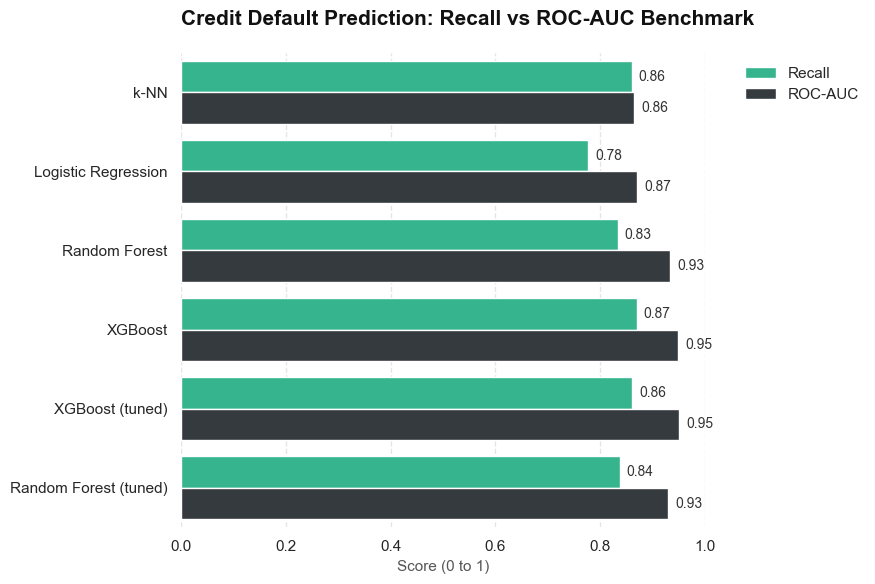

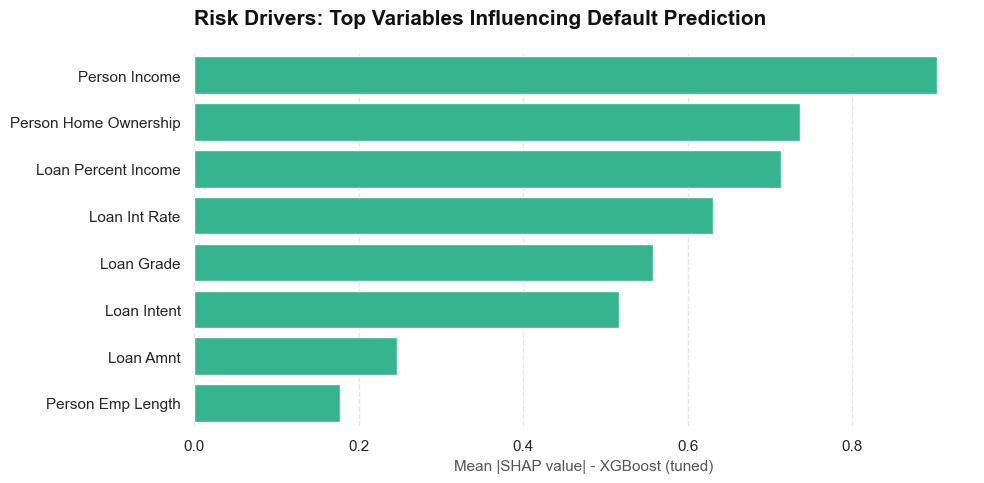

In [32]:
# --- Generating Professional ML Visuals for Credit Risk Portfolio ---
# Setting up a clean, corporate visual style
sns.set_theme(style="white", palette="muted")
plt.rcParams.update({'font.family': 'sans-serif'})

# ---------------------------------------------------------
# Visual 1: Model Benchmark (Recall and ROC-AUC, tuned threshold)
# ---------------------------------------------------------
# Recall is the key metric in credit risk: it is the share of real defaulters the model catches
df_bench = results_df[results_df['Threshold'] == 'tuned'][['Model', 'Recall', 'ROC-AUC']]
df_melted = df_bench.melt(id_vars="Model", value_vars=["Recall", "ROC-AUC"], var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(data=df_melted, x="Score", y="Model", hue="Metric", palette=["#20c997", "#343a40"], ax=ax)

ax.set_title("Credit Default Prediction: Recall vs ROC-AUC Benchmark", fontsize=15, fontweight='bold', pad=20, loc='left', color='#111111')
ax.set_xlabel("Score (0 to 1)", fontsize=11, color='#555555')
ax.set_ylabel("", fontsize=11)
ax.set_xlim(0, 1.0)

sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Adding labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=10, color='#333333')

# Placing the legend nicely
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("credit_risk_benchmark.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Visual 2: Risk drivers (mean |SHAP value| of the best model, grouped by ORIGINAL variable)
# ---------------------------------------------------------
# One-hot encoding splits a variable (e.g. loan_grade) into several columns.
# SHAP values are additive, so a variable's contribution to one client is the SUM of the signed SHAP values of its
# columns. The absolute value is taken AFTER that sum: taking |.| first would add up the magnitudes of columns that
# push in opposite directions and inflate every categorical variable.
prep = best_model.named_steps['prep']
final_model = best_model.named_steps['model']
feature_names = prep.get_feature_names_out()

def original_variable(feature_name):
    """Maps an encoded column back to the variable it came from."""
    name = re.sub(r'^(num|cat)__', '', feature_name).replace('missingindicator_', '')
    for col in cat_cols:
        if name.startswith(col + '_'):
            return col
    return name

shap_sample = X_test.sample(n=2000, random_state=SEED)   # a sample keeps SHAP fast
X_sample_t = prep.transform(shap_sample)
if hasattr(X_sample_t, 'toarray'):
    X_sample_t = X_sample_t.toarray()

shap_values = shap.TreeExplainer(final_model)(X_sample_t).values
if shap_values.ndim == 3:            # some models return one set of values per class
    shap_values = shap_values[:, :, 1]

shap_df = pd.DataFrame(shap_values, columns=[original_variable(f) for f in feature_names])   # signed values: no np.abs here
importance_by_variable = shap_df.T.groupby(level=0).sum().T.abs().mean().sort_values(ascending=False)

features_df = importance_by_variable.head(8).rename_axis('Feature').reset_index(name='Importance')

# Cleaning feature names for business presentation
features_df['Feature'] = features_df['Feature'].str.replace('_', ' ').str.title()
features_df['Feature'] = features_df['Feature'].str.replace('Cb Person Default On File', 'Prior Default History')

fig2, ax2 = plt.subplots(figsize=(10, 5))

sns.barplot(data=features_df, x="Importance", y="Feature", color="#20c997", ax=ax2)

ax2.set_title("Risk Drivers: Top Variables Influencing Default Prediction", fontsize=15, fontweight='bold', pad=20, loc='left', color='#111111')
ax2.set_xlabel(f"Mean |SHAP value| - {best_name}", fontsize=11, color='#555555')
ax2.set_ylabel("", fontsize=11)

sns.despine(left=True, bottom=True)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("credit_risk_features.png", dpi=300, bbox_inches='tight')
plt.show()


### Direction of the risk drivers
The bar chart above shows *how much* each variable matters. The beeswarm below shows *in which direction*: each dot is a client, its horizontal position is how much that variable pushes the client's risk up (right) or down (left), and its color is the variable's value (red = high, blue = low). One-hot columns (such as each loan grade) appear separately here.


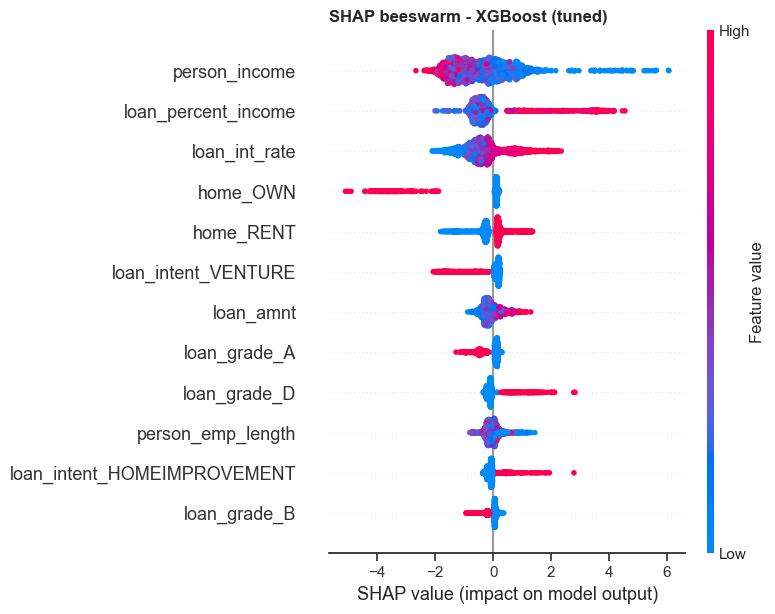

In [33]:

# --- SHAP beeswarm: direction and spread of each variable's effect ---
def pretty(feature_name):
    name = re.sub(r'^(num|cat)__', '', feature_name).replace('missingindicator_', 'missing: ')
    return name.replace('cb_person_default_on_file', 'prior_default').replace('person_home_ownership', 'home')

plt.figure()
shap.summary_plot(shap_values, X_sample_t, feature_names=[pretty(f) for f in feature_names],
                  max_display=12, show=False)
plt.title(f"SHAP beeswarm - {best_name}", fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig("credit_risk_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()


In [34]:
# --- Scoring every client ---
# Probabilities are CALIBRATED and OUT-OF-FOLD: each client is scored by a model that never saw that client
# during training, so the scores are honest estimates and not inflated by memorization.
decision_threshold = cal_threshold

def run_portfolio_scores():
    return cross_val_predict(clone(calibrated_model), X, y, cv=cv, method='predict_proba')[:, 1]

oof_scores = cached('portfolio_scores', run_portfolio_scores, X, y, clone(calibrated_model), repr(cv))

cr_scored = cr_bi.copy()
cr_scored['default_probability'] = oof_scores.round(4)
cr_scored['predicted_default'] = (oof_scores >= decision_threshold).astype(int)

# Risk bands: Low / Medium below the decision threshold, High at or above it
low_cut = min(0.20, decision_threshold / 2)
cr_scored['risk_band'] = pd.cut(oof_scores, bins=[-0.01, low_cut, decision_threshold, 1.01],
                                labels=['Low', 'Medium', 'High'])
# Expected credit loss = PD x LGD x EAD (EAD = loan amount, assumed fully drawn)
cr_scored['expected_loss'] = (oof_scores * LGD * cr_scored['loan_amnt']).round(2)

# Export the scored portfolio and the supporting tables
cr_scored.to_csv('credit_risk_scored.csv', index=False)
results_df.to_csv('model_comparison.csv', index=False)
importance_by_variable.rename('mean_abs_shap').rename_axis('variable').reset_index().to_csv('feature_importance.csv', index=False)

print(f"Scored {len(cr_scored)} clients with {best_name} (calibrated, threshold = {decision_threshold:.2f})")
print("\nObserved default rate by risk band (should rise from Low to High):")
band_table = cr_scored.groupby('risk_band', observed=True).agg(
    clients=('loan_status', 'size'),
    observed_default_rate=('loan_status', 'mean'),
    mean_predicted_pd=('default_probability', 'mean'),
    total_loan_amount=('loan_amnt', 'sum'),
    expected_loss=('expected_loss', 'sum'),
)
band_table['share_of_expected_loss'] = band_table['expected_loss'] / band_table['expected_loss'].sum()
band_table.round(3)

portfolio_scores: loaded from cache in 0 s
Scored 32409 clients with XGBoost (tuned) (calibrated, threshold = 0.17)

Observed default rate by risk band (should rise from Low to High):


,clients,observed_default_rate,mean_predicted_pd,total_loan_amount,expected_loss,share_of_expected_loss
risk_band,,,,,,
Low,17364,0.021,0.039,164240650,3865339.99,0.084
Medium,7302,0.114,0.118,64647425,4539367.59,0.098
High,7743,0.761,0.718,81994825,37692988.68,0.818


In [35]:
# --- Risk bands on the held-out TEST set: two ways of looking at it ---
# The band table above covers the WHOLE portfolio (out-of-fold scores of all 32,409 clients). For the 30% test set:
#  (a) the model fitted on the training set only, scored on the test clients: what a deployed model would do on new clients;
#  (b) the out-of-fold scores of the table above, restricted to the test clients.
test_positions = X.index.get_indexer(X_test.index)
band_edges, band_labels = [-0.01, low_cut, decision_threshold, 1.01], ['Low', 'Medium', 'High']

def band_summary(scores, outcome):
    bands = pd.cut(scores, bins=band_edges, labels=band_labels)
    return (pd.DataFrame({'band': bands, 'default': np.asarray(outcome)})
              .groupby('band', observed=True)['default'].agg(clients='size', observed_default_rate='mean').round(3))

print("(a) Model fitted on the training set, scored on the test set (calibrated):")
table_a = band_summary(cal_test_proba, y_test)
print(table_a.to_string())
print(f"    share of test clients flagged High: {table_a.loc['High', 'clients'] / len(y_test):.1%}")
print("\n(b) Out-of-fold scores of the whole-portfolio table, restricted to the test clients:")
table_b = band_summary(oof_scores[test_positions], y_test)
print(table_b.to_string())
print(f"    share of test clients flagged High: {table_b.loc['High', 'clients'] / len(y_test):.1%}")

(a) Model fitted on the training set, scored on the test set (calibrated):
        clients  observed_default_rate
band                                  
Low        5767                  0.028
Medium     1286                  0.114
High       2670                  0.681
    share of test clients flagged High: 27.5%

(b) Out-of-fold scores of the whole-portfolio table, restricted to the test clients:
        clients  observed_default_rate
band                                  
Low        5186                  0.021
Medium     2206                  0.113
High       2331                  0.757
    share of test clients flagged High: 24.0%


### The risk bands work
The table above covers the **whole portfolio** (32,409 clients, each scored out-of-fold). Observed default rates rise sharply across the bands, and the calibrated PD follows them, with a bias of a few points at the ends: it overstates the Low band (mean predicted PD 3.9% against 2.1% observed) and understates the High band (71.8% against 76.1%), while the Medium band is close (11.8% against 11.4%):

| Risk band | Clients | Observed default rate | Share of expected loss |
|---|---|---|---|
| Low | 17,364 (54%) | 2.1% | 8% |
| Medium | 7,302 (23%) | 11.4% | 10% |
| High | 7,743 (24%) | 76.1% | 82% |

`expected_loss` is PD x LGD x EAD with the 60% LGD from section 7; change `LGD` in the notebook and re-run to update it. These figures replaced the earlier ones (77% of expected loss in High) because the bands now use the calibrated probabilities and the calibrated threshold (0.17).

**On the held-out test set** (cell above) the picture depends on how the test clients are scored. For the model fitted on the training set and applied to the test clients, which is what a deployed model would do on new clients, the observed default rates are 2.8% (Low, 5,767 clients), 11.4% (Medium, 1,286) and **68.1%** (High, 2,670). The out-of-fold scores restricted to the same test clients give 2.1% / 11.3% / 75.7% (5,186 / 2,206 / 2,331 clients). The High band is less pure in the first view because the final calibrated model flags more test clients at the same 0.17 threshold (27.5% against 24.0%), and its 68.1% matches the precision reported in section 7. For new clients, expect the first set of numbers.

## 8b. A data check: where does the ROC-AUC of 0.95 come from?
A ROC-AUC this high on credit data deserves a check before it is trusted. The cell below looks for a group of clients whose outcome is fully determined, and measures how much the score depends on it. It uses the out-of-fold scores computed above.

In [36]:
# --- Data check: is part of the performance explained by a near-deterministic group? ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 1) The group: renters whose loan is at least 31% of their income
rent_high_burden = (cr_scored['person_home_ownership'] == 'RENT') & (cr_scored['loan_percent_income'] >= 0.31)
n_group = int(rent_high_burden.sum())
defaults_in_group = int(cr_scored.loc[rent_high_burden, 'loan_status'].sum())
total_defaults = int(cr_scored['loan_status'].sum())
print(f"RENT and loan_percent_income >= 0.31: {n_group:,} clients, {defaults_in_group:,} defaults ({defaults_in_group / n_group:.1%})")
print(f"  = {n_group / len(cr_scored):.1%} of the clients and {defaults_in_group / total_defaults:.1%} of all defaults")

# The boundary is sharp: renters just below the cut default at an ordinary rate
renters = cr_scored[cr_scored['person_home_ownership'] == 'RENT']
just_below = renters[(renters['loan_percent_income'] >= 0.28) & (renters['loan_percent_income'] < 0.31)]
print(f"RENT with loan_percent_income from 0.28 to 0.30: {len(just_below):,} clients, default rate {just_below['loan_status'].mean():.1%}")

# 2) How far does a tiny model get? (the preprocessing is fitted on all rows here, which is harmless for a 2-level tree)
X_encoded = make_preprocessor().fit_transform(X)
for depth in (1, 2):
    auc = cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=SEED), X_encoded, y, cv=cv, scoring='roc_auc')
    print(f"Decision tree, depth {depth}: cross-validated ROC-AUC {auc.mean():.3f}")

# 3) How much does the score depend on that group? (out-of-fold scores, group removed)
in_group = rent_high_burden.to_numpy()
y_arr = y.to_numpy()
print(f"Out-of-fold ROC-AUC, all clients:         {roc_auc_score(y_arr, oof_scores):.3f}   PR-AUC {average_precision_score(y_arr, oof_scores):.3f}")
print(f"Out-of-fold ROC-AUC, without that group:  {roc_auc_score(y_arr[~in_group], oof_scores[~in_group]):.3f}   PR-AUC {average_precision_score(y_arr[~in_group], oof_scores[~in_group]):.3f}   (n = {int((~in_group).sum()):,})")

# 4) Calibrated probabilities of exactly 1.0 and 0.0 (out-of-fold)
pd_scores = cr_scored['default_probability']
for value in (1.0, 0.0):
    sel = pd_scores == value
    print(f"PD = {value:.1f}: {int(sel.sum()):,} clients, {int(cr_scored.loc[sel, 'loan_status'].sum()):,} defaults; {int((sel & rent_high_burden).sum()):,} of them in the renter group above")

RENT and loan_percent_income >= 0.31: 2,339 clients, 2,339 defaults (100.0%)
  = 7.2% of the clients and 33.0% of all defaults
RENT with loan_percent_income from 0.28 to 0.30: 814 clients, default rate 30.5%


Decision tree, depth 1: cross-validated ROC-AUC 0.667
Decision tree, depth 2: cross-validated ROC-AUC 0.796


Out-of-fold ROC-AUC, all clients:         0.951   PR-AUC 0.907
Out-of-fold ROC-AUC, without that group:  0.926   PR-AUC 0.823   (n = 30,070)
PD = 1.0: 3,477 clients, 3,477 defaults; 2,213 of them in the renter group above
PD = 0.0: 2,135 clients, 0 defaults; 0 of them in the renter group above


### What the data check shows
- **One group is fully deterministic.** Every one of the 2,339 renters whose loan is at least 31% of their income defaulted, with no exception, and the boundary is sharp: renters just below the cut (28% to 30%) default 30.5% of the time. The group is 7.2% of the clients and 33.0% of all defaults.
- **A tiny model already ranks well.** A decision tree with two levels reaches a cross-validated ROC-AUC of about 0.80 (a single split gives about 0.67).
- **Without that group the score is weaker.** On the out-of-fold scores, removing those 2,339 clients lowers the ROC-AUC from 0.951 to 0.926 and the PR-AUC from 0.907 to 0.823.
- **Some calibrated probabilities are exactly 1.0 or 0.0.** 3,477 clients have PD = 1.0 (all of them defaulted) and 2,135 have PD = 0.0 (none defaulted). This is not a calibration bug: isotonic calibration returns the observed default rate of a score range, and in these ranges the observed rate is 100% or 0%. The renter group above accounts for 2,213 of the 3,477 clients with PD = 1.0; the other 1,264 come from other near-deterministic segments, more than half of them grade D loans. No floor or cap was applied to the PDs.

Real credit portfolios rarely contain rules this clean, so the labels of this public dataset look rule-generated. The ROC-AUC of 0.95 and the 81% simulated saving should therefore be read as an **upper bound for this dataset**, not as an expectation for real data.

## 9. Conclusions and recommendations
1. **Default is predictable.** The tuned XGBoost reaches a ROC-AUC of 0.95. At the same 0.5 cutoff it catches 80.5% of defaulters against 61.1% for the k-NN baseline, with the same precision; at its recall-first cutoff (0.35) it catches 86.1%, with precision falling to 66.8%. Without `loan_grade` and `loan_int_rate` it still reaches a ROC-AUC of 0.90, so the signal is not only the lender's own score.
2. **The model is worth using under any reasonable cost assumption.** The simulated loss falls by 75.5% to 84.3% versus approving every loan across all scenarios tested.
3. **A three-tier policy is supported by the data.** Auto-approve the **Low** band (54% of clients, 2.1% default), send **Medium** to manual review, and decline or reprice **High** (24% of clients, 76% default, about 82% of expected losses).
4. **Watch the high-risk segments:** grades D to G, renters, debt consolidation / medical / home improvement loans, and loans above 30% of income.
5. **The threshold is a business decision, not a technical one.** The cost-optimal cutoff ranges from about 0.10 to 0.67 depending on the assumed loss on default and the interest margin, so it must be set with the institution's real costs.

### Limitations and next steps
- **Labels that look rule-generated.** Section 8b shows that all 2,339 renters with a loan of at least 31% of their income defaulted, with no exception (33% of all defaults), and that a two-level decision tree already reaches a ROC-AUC of about 0.80. The ROC-AUC of 0.95 and the 81% simulated saving are therefore an upper bound for this dataset, not an expectation for real data.
- **No time dimension.** The data is a snapshot, so the model could not be validated out-of-time or monitored for drift. IFRS 9 also requires point-in-time, forward-looking PDs, staging and discounting, none of which are modeled here.
- **Circularity, tested.** `loan_grade` and `loan_int_rate` encode the lender's own risk assessment. Without both, ROC-AUC falls from 0.95 to 0.90 (section 6): part of the power is reproduced pricing, but a substantial independent signal remains.
- **Illustrative USD costs.** The dataset is in US dollars and the LGD and interest assumptions are not in the data; the framing (PD x LGD x EAD) is what carries over to a European setting.
- **Selection bias.** Only approved loans have outcomes; rejected applicants are unobserved.
- **Fairness, GDPR and EU rules.** Under GDPR Article 22, a fully automated decision with significant effects on a person (such as a credit refusal) requires safeguards: human review, an explanation and the right to contest. The EU AI Act also treats credit scoring of individuals as high-risk. Age may be restricted or require justification under EU and Irish anti-discrimination rules, so it should be reviewed before real use; the test in section 6 shows removing `person_age` costs almost nothing (ROC-AUC 0.950 → 0.948). This is a technical note, not legal advice.
- **Next steps:** out-of-time validation, a fairness audit across protected groups and a monitoring plan (calibration drift included).